In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d

d-space range: 0.053–7.499 Å
Intensity range: 0.000–92257.731
Total number of peaks: 12
Peak indices: [105 126 153 180 191 204 242 263 284 321 338 531]
Selected top 3 peak indices: [531 321 180]


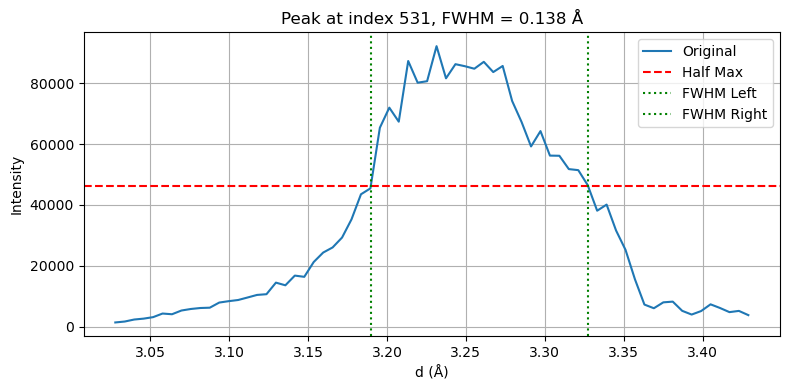

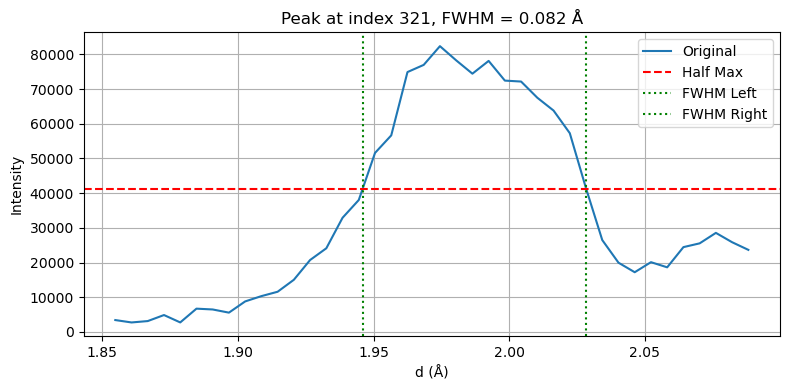

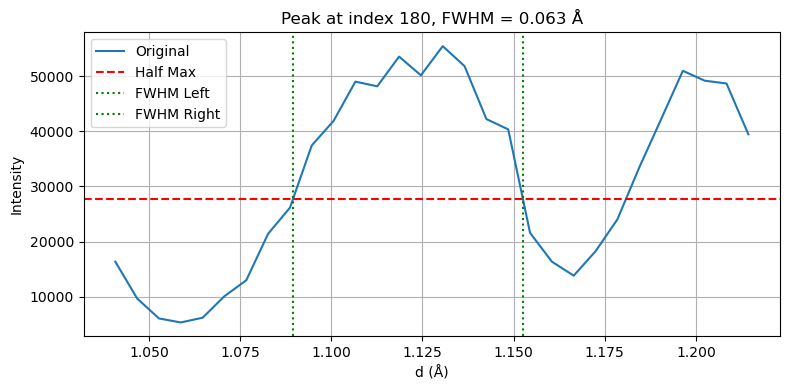

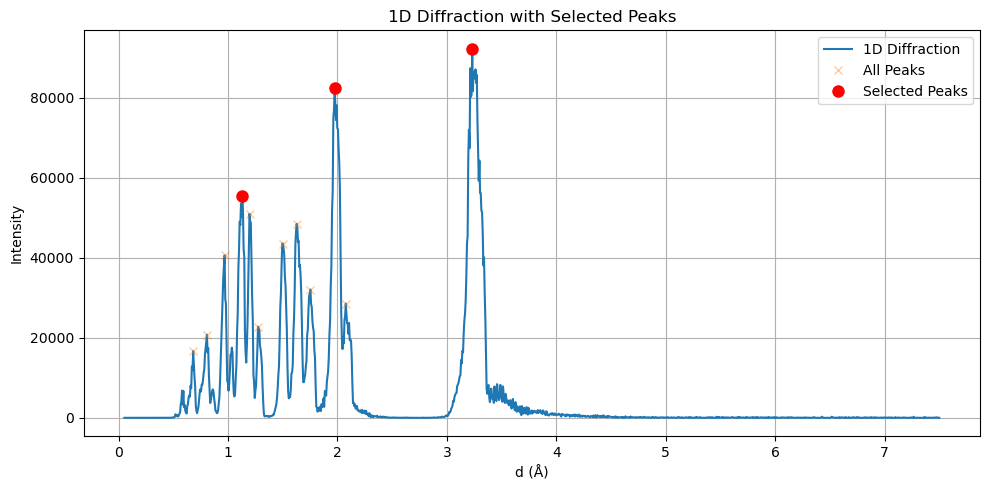


Peak Analysis Results:
   index  d_center     intensity  integral_intensity  center_of_mass  \
0    531  3.231421  92257.730866        2.273158e+06        3.248109   
1    321  1.974491  82358.445162        1.375208e+06        1.991119   
2    180  1.130552  55458.305246        9.424128e+05        1.141928   

       fwhm  relative_resolution  
0  0.137734             0.042404  
1  0.082485             0.041427  
2  0.063044             0.055208  


In [5]:
# Load data
npy_path = r'/Users/artempopov/PycharmProjects/ML_Project/DifClassification/Na2Ca3Al2F14_test_diffraction_numpy.npy'
csv_path = r'/Users/artempopov/PycharmProjects/ML_Project/DifClassification/C_graphite_test_d_space_filtered_diffracion.csv'
diffraction_2d = np.load(npy_path)
df_1d = pd.read_csv(csv_path)

# Apply d-space scaling correction
d = df_1d['d'].values * 0.25
I = df_1d['I'].values

# Check d-space range and data sanity
print(f"d-space range: {min(d):.3f}–{max(d):.3f} Å")
print(f"Intensity range: {min(I):.3f}–{max(I):.3f}")
if len(d) != len(I):
    raise ValueError("Length of d and I arrays do not match!")

# Find peaks with tuned parameters, including width
peaks, properties = find_peaks(I, height=0.05, distance=10, prominence=0.1, width=5)
print(f"Total number of peaks: {len(peaks)}")
print(f"Peak indices: {peaks}")

# Select top 3 peaks by intensity
top_3_peaks = peaks[np.argsort(properties['peak_heights'])[-3:]][::-1]  # Sort descending
print(f"Selected top 3 peak indices: {top_3_peaks}")

#top_3_peaks = np.append(top_3_peaks, [peaks[-1]])
#print(f"Selected top 3 peak indices: {top_3_peaks}")

def extract_peak_region(d, I, peak_idx, properties, scale_factor=1.5, default_window=15):
    # Find the index of peak_idx in peaks array
    try:
        peak_array_idx = np.where(peaks == peak_idx)[0][0]
    except IndexError:
        print(f"Error: peak_idx {peak_idx} not found in peaks array!")
        return d[peak_idx:peak_idx+1], I[peak_idx:peak_idx+1]
    
    # Use adaptive window based on estimated peak width
    if 'widths' in properties:
        window = int(properties['widths'][peak_array_idx] * scale_factor)
    else:
        window = default_window
        print(f"Warning: 'widths' not found for peak {peak_idx}, using default window {default_window}")
    start = max(peak_idx - window, 0)
    end = min(peak_idx + window, len(d))
    return d[start:end], I[start:end]

def center_of_mass(d, I):
    total_I = np.sum(I)
    return np.sum(d * I) / total_I if total_I != 0 else np.nan

def compute_fwhm_local(d_local, I_local):
    if len(d_local) < 2:
        return np.nan, None, None
        
    I_peak = np.max(I_local)
    half_max = I_peak / 2
    peak_idx_local = np.argmax(I_local)
    d_peak = d_local[peak_idx_local]
    
    # Инициализация границ
    d_left, d_right = np.nan, np.nan
    
    # Поиск левой границы (сканирование от пика влево)
    for i in range(peak_idx_local, 0, -1):
        if I_local[i] >= half_max and I_local[i-1] < half_max:
            # Линейная интерполяция между точками
            x1, y1 = d_local[i-1], I_local[i-1]
            x2, y2 = d_local[i], I_local[i]
            d_left = x1 + (x2 - x1) * (half_max - y1) / (y2 - y1)
            break
        elif i == 1 and I_local[0] >= half_max:
            d_left = d_local[0]
            break
    
    # Поиск правой границы (сканирование от пика вправо)
    for i in range(peak_idx_local, len(I_local)-1):
        if I_local[i] >= half_max and I_local[i+1] < half_max:
            # Линейная интерполяция между точками
            x1, y1 = d_local[i], I_local[i]
            x2, y2 = d_local[i+1], I_local[i+1]
            d_right = x1 + (x2 - x1) * (half_max - y1) / (y2 - y1)
            break
        elif i == len(I_local)-2 and I_local[-1] >= half_max:
            d_right = d_local[-1]
            break
    
    # Проверка успешности определения границ
    if np.isnan(d_left) or np.isnan(d_right):
        print(f"Warning: Failed to find both boundaries for peak at {d_peak:.3f} Å")
        return np.nan, None, None
    
    fwhm = d_right - d_left
    return fwhm, d_left, d_right

def plot_peak_region(d_window, I_window, peak_idx, fwhm, d_left=None, d_right=None):
    plt.figure(figsize=(8, 4))
    plt.plot(d_window, I_window, label='Original')
    plt.axhline(np.max(I_window) / 2, color='r', linestyle='--', label='Half Max')
    if d_left is not None and d_right is not None:
        plt.axvline(d_left, color='g', linestyle=':', label='FWHM Left')
        plt.axvline(d_right, color='g', linestyle=':', label='FWHM Right')
    plt.title(f'Peak at index {peak_idx}, FWHM = {fwhm:.3f} Å')
    plt.xlabel('d (Å)')
    plt.ylabel('Intensity')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Analyze selected peaks
results = []
for peak_idx in top_3_peaks:
    d_window, I_window = extract_peak_region(d, I, peak_idx, properties, scale_factor=1.5, default_window=15)
    #integral_intensity = np.trapz(I_window, d_window)
    integral_intensity = sum(I_window)
    com = center_of_mass(d_window, I_window)
    
    # Compute FWHM with additional checks
    fwhm, d_left, d_right = compute_fwhm_local(d_window, I_window)
    rel_res = fwhm / com if com != 0 and not np.isnan(fwhm) else np.nan

    # Plot peak region for diagnostics
    plot_peak_region(d_window, I_window, peak_idx, fwhm, d_left, d_right)

    results.append({
        "index": peak_idx,
        "d_center": d[peak_idx],
        "intensity": I[peak_idx],
        "integral_intensity": integral_intensity,
        "center_of_mass": com,
        "fwhm": fwhm,
        "relative_resolution": rel_res
    })

# Plot overall diffraction pattern
plt.figure(figsize=(10, 5))
plt.plot(d, I, label='1D Diffraction', lw=1.5)
plt.plot(d[peaks], I[peaks], 'x', label='All Peaks', alpha=0.4)
plt.plot(d[top_3_peaks], I[top_3_peaks], 'ro', label='Selected Peaks', markersize=8)
plt.xlabel("d (Å)")
plt.ylabel("Intensity")
plt.title("1D Diffraction with Selected Peaks")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output results
results_df = pd.DataFrame(results)
print("\nPeak Analysis Results:")
print(results_df)

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

"""
# Загрузка DataFrame из файла
with open('/Users/artempopov/PycharmProjects/ML_Project/DifClassification/dataset.pkl', 'rb') as f:
    df = pickle.load(f)

"""

class Qwrapper:
    def __init__(self, thettta_resolution, Lambda_resolution):
        self.thettta_resolution = thettta_resolution
        self.Lambda_resolution = Lambda_resolution

    def getQDIFADC(self, matrix, num_channels):

        rad_coeff = 0.0174533
        thetta = np.linspace(-170,170, self.thettta_resolution)
        L = np.linspace(0.1, 10, self.Lambda_resolution)
        Q = []
        I = []

        for rows in range(len(matrix)):
            for cols in range(len(matrix[rows])):
                #q = L[rows] * np.sin(abs(rad_coeff * thetta[cols]))/ (4*np.pi)
                #q = 4*np.pi / (np.sin(abs(rad_coeff * thetta[cols])) * L[rows])
                #q = L[rows] / (np.sin(abs(rad_coeff * thetta[cols])) / 4*np.pi)
                #q = L[rows] / (np.sin(abs(rad_coeff * thetta[cols]/2)) / 2)
                q = L[rows] / (np.sin(abs(rad_coeff * thetta[cols]/2)) * 2)
                Q.append(q)
                I.append(abs(matrix[rows][cols]))

        # Определение диапазона и количества каналов
        qmin = np.min(Q)
        qmax = np.max(Q)
        #num_channels = 2024

        # Определение границ каналов
        channels = np.linspace(qmin, qmax, num_channels + 1)

        # Определение индексов каналов для каждого значения Q
        channel_indices = np.digitize(Q, channels) - 1

        # Инициализация массива для хранения сумм I по каналам
        I_summed = np.zeros(num_channels)

        # Накопление значений I в соответствующих каналах
        for i in range(len(Q)):
            if 0 <= channel_indices[i] < num_channels:
                I_summed[channel_indices[i]] += I[i]

        # Построение графика
        channel_centers = (channels[:-1] + channels[1:]) / 2  # центры каналов

        return channel_centers, I_summed
    
    def getQDIFSORT(self, matrix):

        rad_coeff = 0.0174533
        thetta = np.linspace(-170,170, self.thettta_resolution)
        L = np.linspace(0.1, 10, self.Lambda_resolution)
        Q = []
        I = []

        for rows in range(len(matrix)):
            for cols in range(len(matrix[rows])):
                #q = L[rows] * np.sin(abs(rad_coeff * thetta[cols]))/ (4*np.pi)
                q = 4*np.pi / (np.sin(abs(rad_coeff * thetta[cols])) * L[rows])
                Q.append(q)
                I.append(abs(matrix[rows][cols]))

        graph = zip(Q,I)

        #отсортируем, взяв первый элемент каждого списка как ключ
        graph_s = sorted(graph, key=lambda tup: tup[0])

        Qs = [x[0] for x in graph_s]
        Is = [x[1] for x in graph_s]

        return Qs, Is
    

class Dwrapper:
    def __init__(self):
        pass

    def transform_Q_to_D(q, I):
        d = 1/q

        return d, I
    
"""
plotter = Qwrapper()

Q, I = plotter.getQDIFADC(df['Matrix'][23], 512)

plt.figure(figsize=(10, 6))
plt.plot(Q, I, label='I(Q)')
plt.xlabel('Q')
plt.ylabel('Summed I')
plt.title('I(Q) with 4096 Channels')
#plt.yscale('log')
plt.legend()
plt.show()
"""
"""
plt.figure(figsize=(10, 6))
plt.plot(channel_centers, I_summed, label='I(Q)')
plt.plot(Qs, Is, label='Is(Qs)')
plt.xlabel('Q')
plt.ylabel('Summed I')
plt.title('I(Q) with 4096 Channels')
#plt.yscale('log')
plt.legend()
plt.show()
"""

"\nplt.figure(figsize=(10, 6))\nplt.plot(channel_centers, I_summed, label='I(Q)')\nplt.plot(Qs, Is, label='Is(Qs)')\nplt.xlabel('Q')\nplt.ylabel('Summed I')\nplt.title('I(Q) with 4096 Channels')\n#plt.yscale('log')\nplt.legend()\nplt.show()\n"

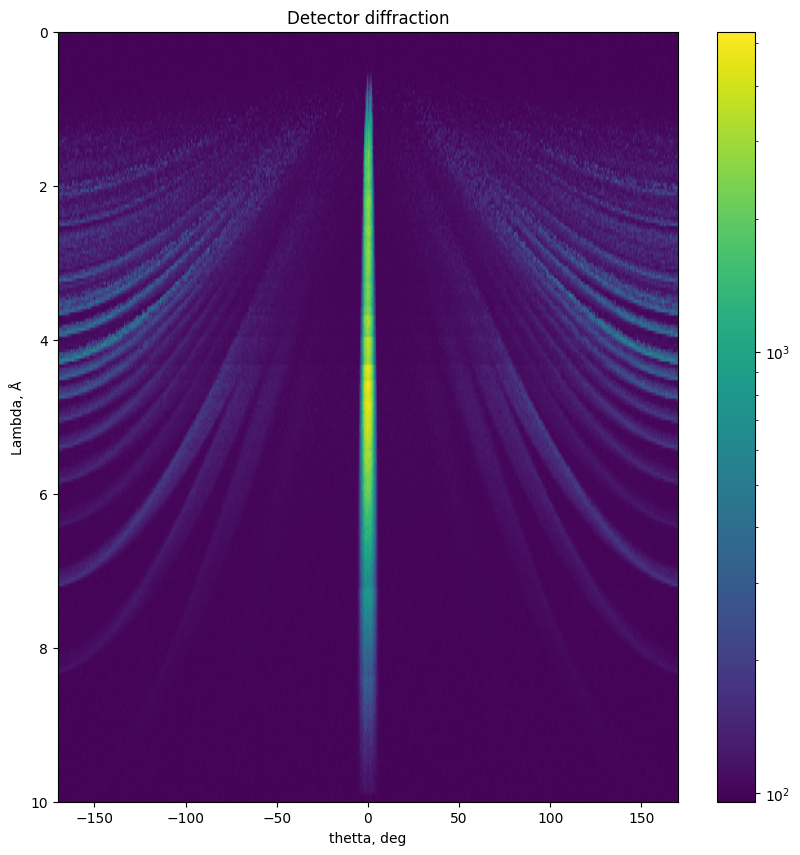

In [60]:
# test crystals - C_graphite Na2Ca3Al2F14

crystal = 'Na2Ca3Al2F14'

diffraction = np.load('Na2Ca3Al2F14_test_diffraction_numpy.npy')

plt.figure(figsize=(10, 10))
plt.imshow(diffraction, cmap='viridis', aspect='auto', norm = 'log', extent=(-170, 170, 10, 0))
plt.title("Detector diffraction")
#plt.axis('off')
plt.xlabel('thetta, deg')
plt.ylabel('Lambda, Å')
plt.colorbar()
plt.show()

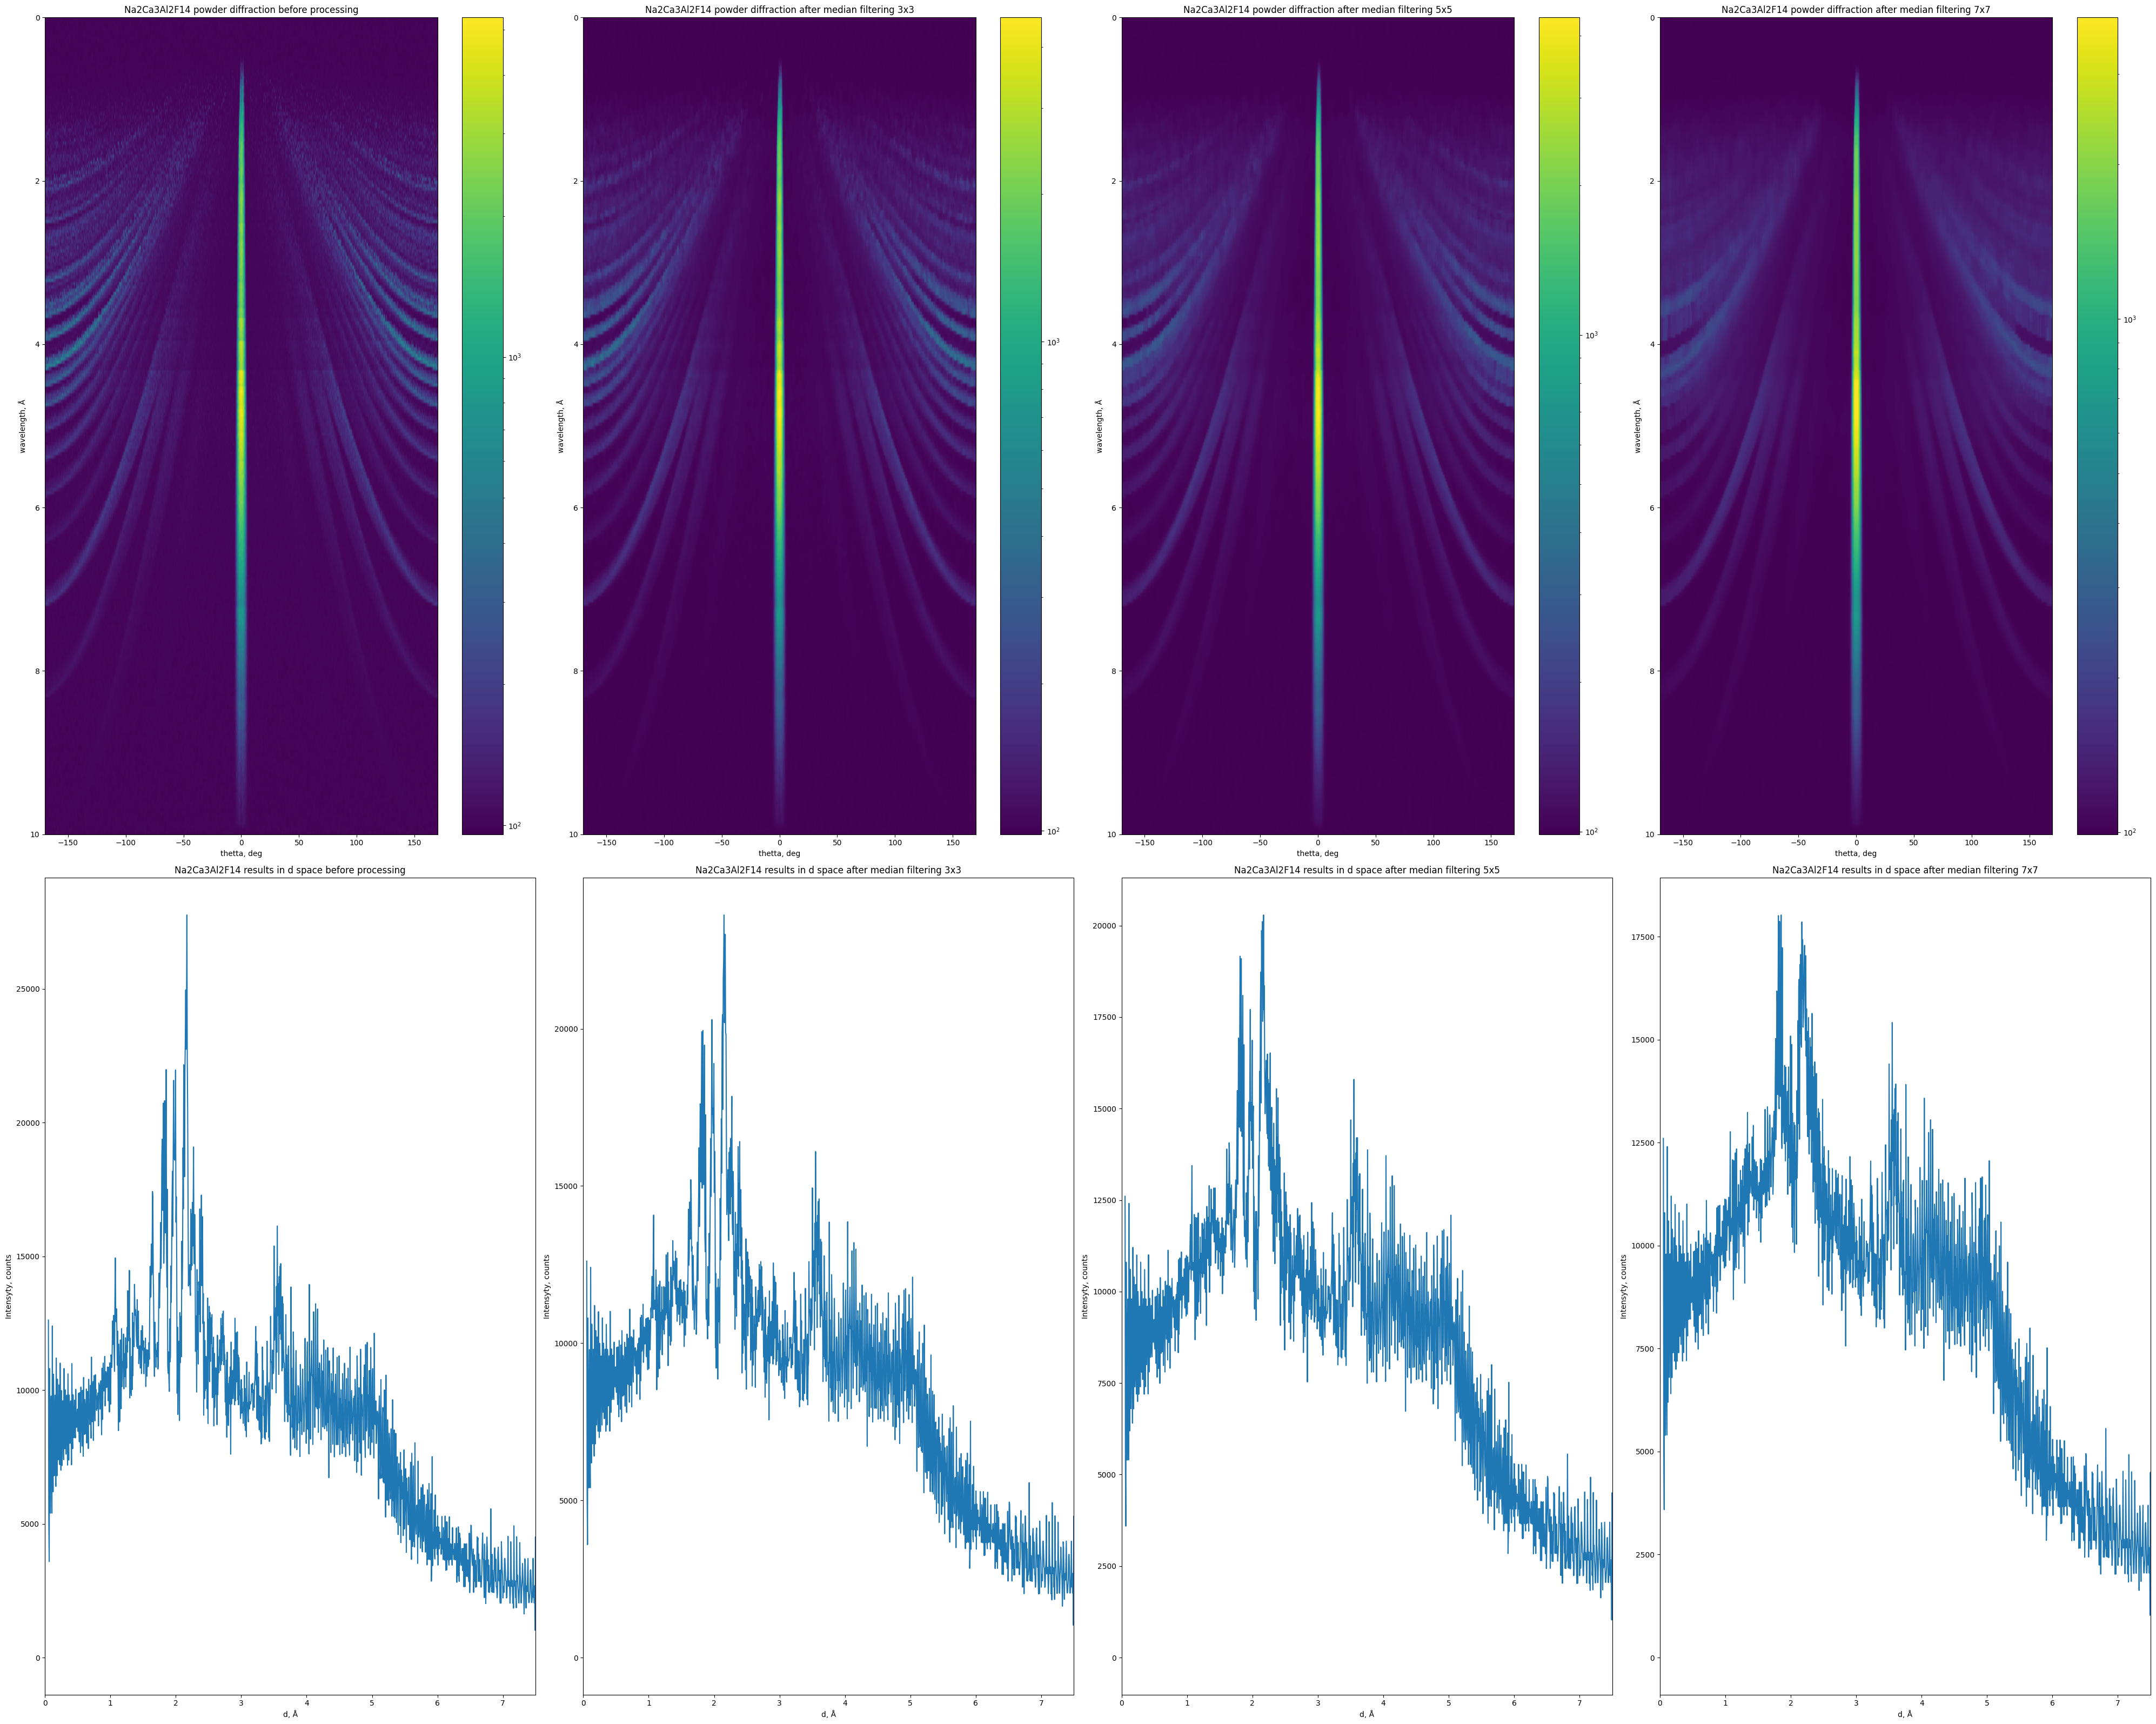

In [73]:
from scipy.ndimage import median_filter


# Применяем медианный фильтр с разными окнами
filtered_image = median_filter(diffraction, size=3, mode='nearest')
filtered_image1 = median_filter(diffraction, size=5, mode='nearest')
filtered_image2 = median_filter(diffraction, size=7, mode='nearest')


Qplotter_low_res = Qwrapper(480, 250)
ADC_chanales = 45000
q1, I1 = Qplotter_low_res.getQDIFADC(diffraction, 6 * ADC_chanales)
q2, I2 = Qplotter_low_res.getQDIFADC(filtered_image, 6 * ADC_chanales)
q3, I3 = Qplotter_low_res.getQDIFADC(filtered_image1, 6 * ADC_chanales)
q4, I4 = Qplotter_low_res.getQDIFADC(filtered_image2, 6 * ADC_chanales)

# Создаем фигуру и оси
fig, axes = plt.subplots(2, 4, figsize=(40, 32))
ax1, ax2, ax3, ax4 = axes[0]  # Первая строка осей
ax5, ax6, ax7, ax8 = axes[1]  # Вторая строка осей

im1 = ax1.imshow(diffraction, cmap='viridis', aspect='auto', norm='log', extent=(-170, 170, 10, 0))
ax1.set_title(f'{crystal} powder diffraсtion before processing')
ax1.set_ylabel('wavelength, Å')
ax1.set_xlabel('thetta, deg')
plt.colorbar(im1)

im2 = ax2.imshow(filtered_image, cmap='viridis', aspect='auto', norm='log', extent=(-170, 170, 10, 0))
ax2.set_title(f'{crystal} powder diffraсtion after median filtering 3x3')
ax2.set_ylabel('wavelength, Å')
ax2.set_xlabel('thetta, deg')
plt.colorbar(im2)

im3 = ax3.imshow(filtered_image1, cmap='viridis', aspect='auto', norm='log', extent=(-170, 170, 10, 0))
ax3.set_title(f'{crystal} powder diffraсtion after median filtering 5x5')
ax3.set_ylabel('wavelength, Å')
ax3.set_xlabel('thetta, deg')
plt.colorbar(im3)

im4 = ax4.imshow(filtered_image2, cmap='viridis', aspect='auto', norm='log', extent=(-170, 170, 10, 0))
ax4.set_title(f'{crystal} powder diffraсtion after median filtering 7x7')
ax4.set_ylabel('wavelength, Å')
ax4.set_xlabel('thetta, deg')
plt.colorbar(im4)

ax5.plot(q1, I1)
#ax3.set_yscale('log')
ax5.set_xlim(0,7.5)
ax5.set_title(f'{crystal} results in d space before processing')
ax5.set_xlabel('d, Å')
ax5.set_ylabel('Intensyty, counts')

ax6.plot(q2, I2)
#ax4.set_yscale('log')
ax6.set_xlim(0,7.5)
ax6.set_title(f'{crystal} results in d space after median filtering 3x3')
ax6.set_xlabel('d, Å')
ax6.set_ylabel('Intensyty, counts')

ax7.plot(q3, I3)
#ax3.set_yscale('log')
ax7.set_xlim(0,7.5)
ax7.set_title(f'{crystal} results in d space after median filtering 5x5')
ax7.set_xlabel('d, Å')
ax7.set_ylabel('Intensyty, counts')

ax8.plot(q4, I4)
#ax4.set_yscale('log')
ax8.set_xlim(0,7.5)
ax8.set_title(f'{crystal} results in d space after median filtering 7x7')
ax8.set_xlabel('d, Å')
ax8.set_ylabel('Intensyty, counts')

plt.tight_layout()
plt.show()

In [74]:
from bm3d import bm3d

# --- Нормализация в [0,1] ---
img_min = diffraction.min()
img_max = diffraction.max()
image_norm = (diffraction - img_min) / (img_max - img_min)

# --- Задаём шум (например если не знаем точно) ---
#sigma_bm3d = 0.02

# Шум можно оценить по фону дифракции как
sigma_bm3d = 100 / (img_max - img_min)
print(sigma_bm3d)

# --- Применяем BM3D ---
denoised_norm = bm3d(image_norm, sigma_psd=sigma_bm3d)

# --- Возвращаем в оригинальный диапазон ---
denoised = denoised_norm * (img_max - img_min) + img_min

0.01916802409796359


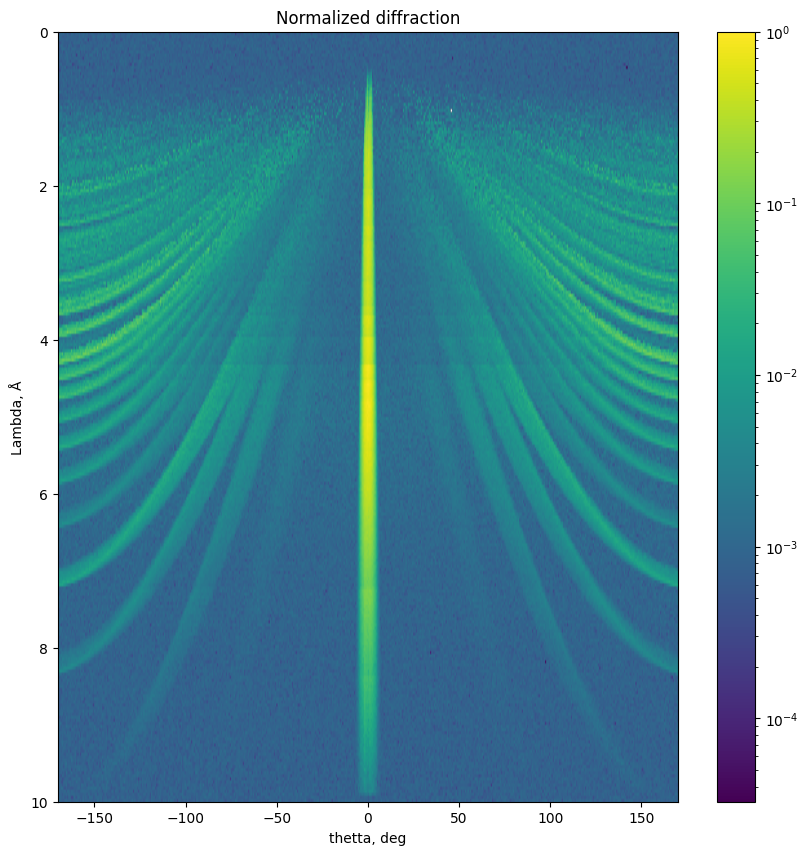

In [53]:
plt.figure(figsize=(10, 10))
plt.imshow(image_norm, cmap='viridis', aspect='auto', norm = 'log', extent=(-170, 170, 10, 0))
plt.title("Normalized diffraction")
#plt.axis('off')
plt.xlabel('thetta, deg')
plt.ylabel('Lambda, Å')
plt.colorbar()
plt.show()

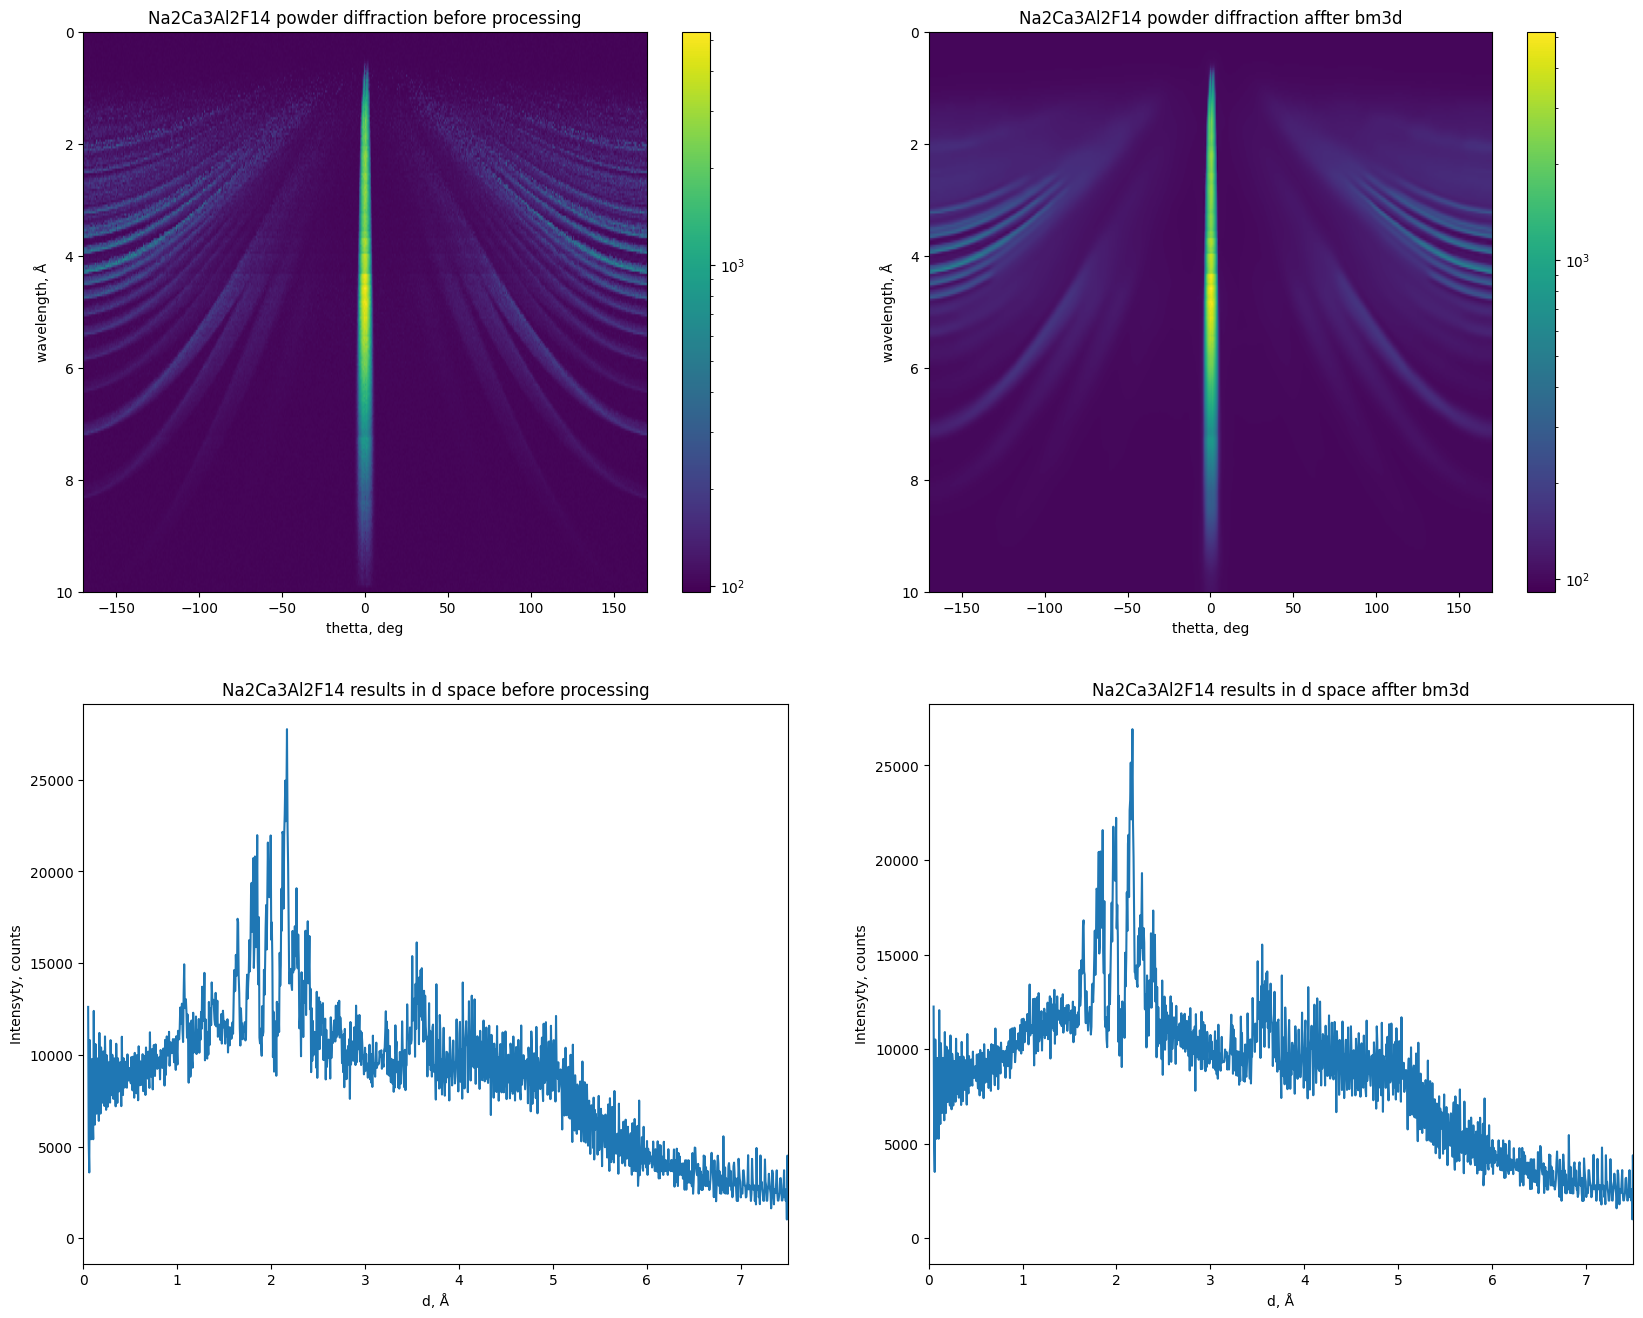

In [54]:
Qplotter_low_res = Qwrapper(480, 250)
ADC_chanales = 45000
q1, I1 = Qplotter_low_res.getQDIFADC(diffraction, 6 * ADC_chanales)
q2, I2 = Qplotter_low_res.getQDIFADC(denoised, 6 * ADC_chanales)

# Создаем фигуру и оси
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
ax1, ax2 = axes[0]  # Первая строка осей
ax3, ax4 = axes[1]  # Вторая строка осей

im1 = ax1.imshow(diffraction, cmap='viridis', aspect='auto', norm='log', extent=(-170, 170, 10, 0))
ax1.set_title(f'{crystal} powder diffraсtion before processing')
ax1.set_ylabel('wavelength, Å')
ax1.set_xlabel('thetta, deg')
plt.colorbar(im1)

im2 = ax2.imshow(denoised, cmap='viridis', aspect='auto', norm='log', extent=(-170, 170, 10, 0))
ax2.set_title(f'{crystal} powder diffraсtion affter bm3d')
ax2.set_ylabel('wavelength, Å')
ax2.set_xlabel('thetta, deg')
plt.colorbar(im2)

ax3.plot(q1, I1)
#ax3.set_yscale('log')
ax3.set_xlim(0,7.5)
ax3.set_title(f'{crystal} results in d space before processing')
ax3.set_xlabel('d, Å')
ax3.set_ylabel('Intensyty, counts')

ax4.plot(q2, I2)
#ax4.set_yscale('log')
ax4.set_xlim(0,7.5)
ax4.set_title(f'{crystal} results in d space affter bm3d')
ax4.set_xlabel('d, Å')
ax4.set_ylabel('Intensyty, counts')

plt.show()

Estimated noise level (log scale): 0.0045
BM3D sigma_psd parameter: 0.0067


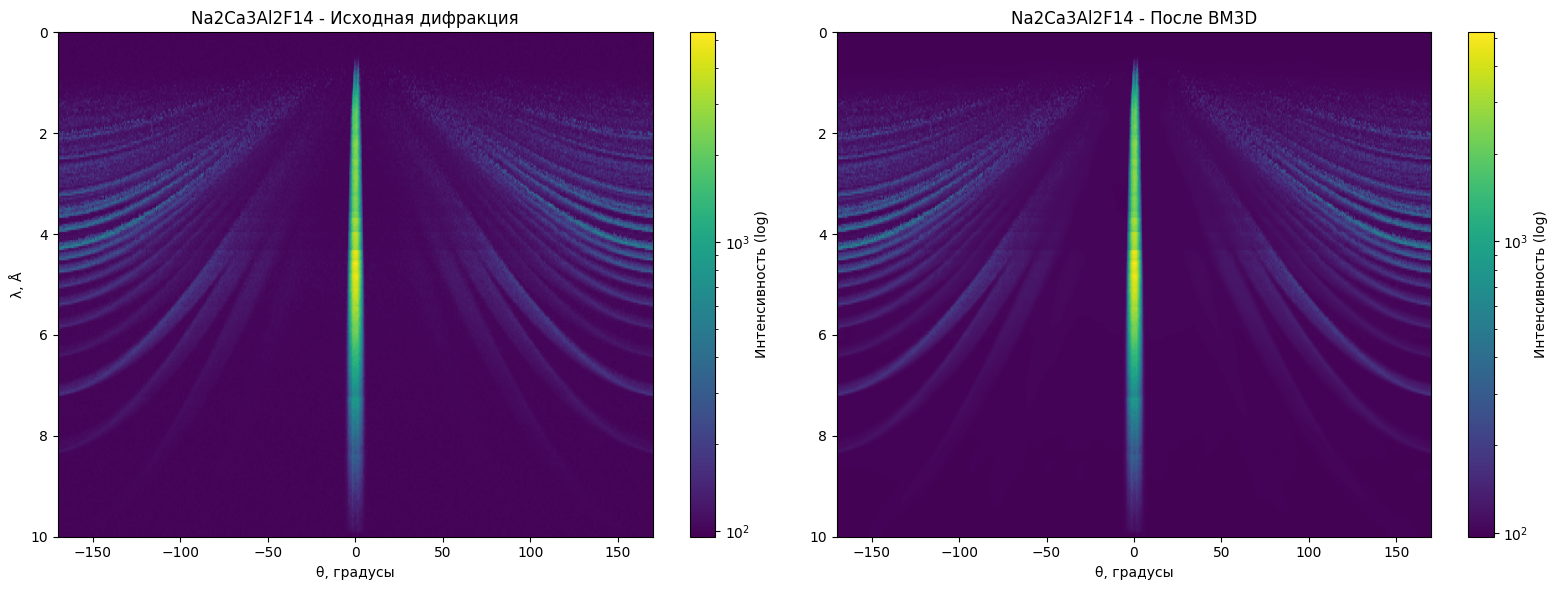

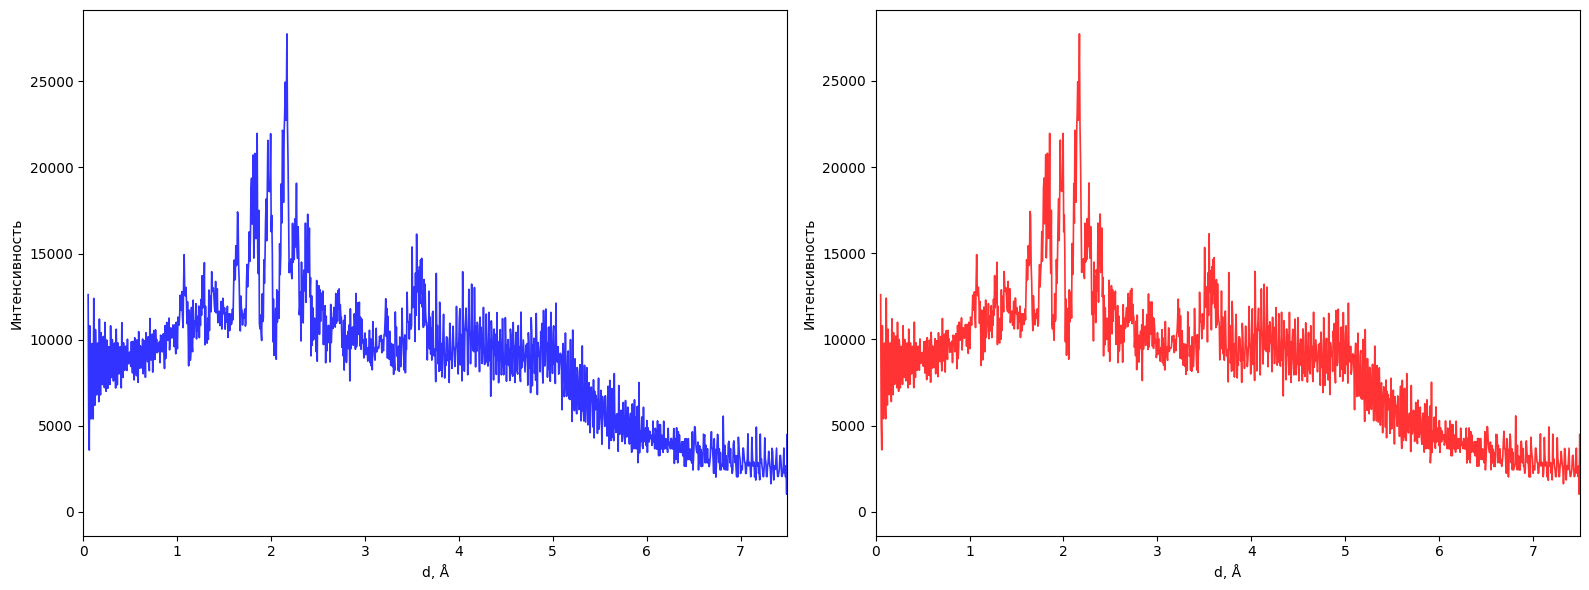

In [91]:
from bm3d import bm3d, BM3DStages
import numpy as np
import matplotlib.pyplot as plt

# --- Нормализация с учетом логарифмического масштаба ---
# Добавляем небольшое значение чтобы избежать log(0)
diffraction_log = np.log10(diffraction + 1e-12)
img_min = diffraction_log.min()
img_max = diffraction_log.max()
image_norm = (diffraction_log - img_min) / (img_max - img_min)

# --- Оценка уровня шума ---
# Метод 1: Оценка по фоновым областям (например, углы изображения)
background = np.concatenate([diffraction[:20,:20].ravel(), 
                           diffraction[-20:,:20].ravel(),
                           diffraction[:20,-20:].ravel(),
                           diffraction[-20:,-20:].ravel()])
sigma_est = np.std(np.log10(background[background > 0] + 1e-12))
sigma_bm3d = sigma_est * 1.5  # Небольшой запас

print(f"Estimated noise level (log scale): {sigma_est:.4f}")
print(f"BM3D sigma_psd parameter: {sigma_bm3d:.4f}")

# --- Параметры BM3D ---
denoised_norm = bm3d(image_norm, 
                    sigma_psd=sigma_bm3d)

# --- Возвращаем к исходному масштабу ---
denoised_log = denoised_norm * (img_max - img_min) + img_min
denoised = 10**denoised_log - 1e-12  # Обратное логарифмическое преобразование
denoised[denoised < 0] = 0           # Убираем возможные отрицательные значения

# --- Визуализация ---
# Строим два отдельных графика для сравнения
plt.figure(figsize=(16, 6))

# График 1: Исходная дифракция
plt.subplot(1, 2, 1)
plt.imshow(diffraction, cmap='viridis', aspect='auto', norm='log', extent=(-170, 170, 10, 0))
plt.title(f'{crystal} - Исходная дифракция')
plt.xlabel('θ, градусы')
plt.ylabel('λ, Å')
plt.colorbar(label='Интенсивность (log)')

# График 2: Обработанная BM3D
plt.subplot(1, 2, 2)
plt.imshow(denoised, cmap='viridis', aspect='auto', norm='log', extent=(-170, 170, 10, 0))
plt.title(f'{crystal} - После BM3D')
plt.xlabel('θ, градусы')
plt.colorbar(label='Интенсивность (log)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(q1, I1, 'b-', alpha=0.8, lw=1.2, label='Исходная')
plt.xlim(0, 7.5)
plt.xlabel('d, Å')
plt.ylabel('Интенсивность')

plt.subplot(1, 2, 2)
plt.plot(q2, I2, 'r-', alpha=0.8, lw=1.2, label='BM3D обработка')
plt.xlim(0, 7.5)
plt.xlabel('d, Å')
plt.ylabel('Интенсивность')

plt.tight_layout()
plt.show()